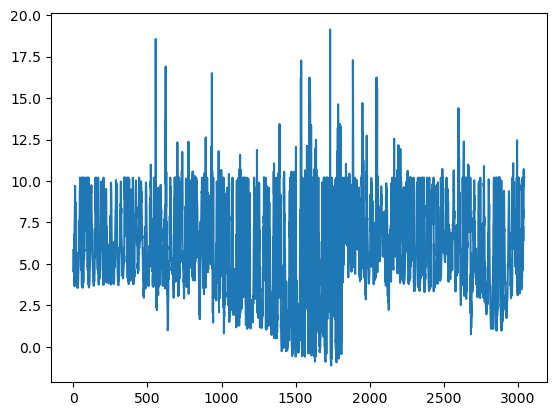

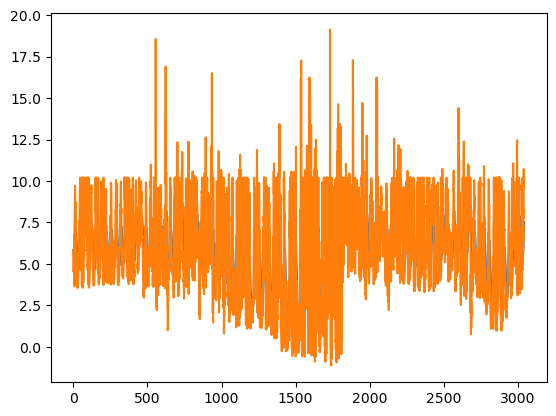

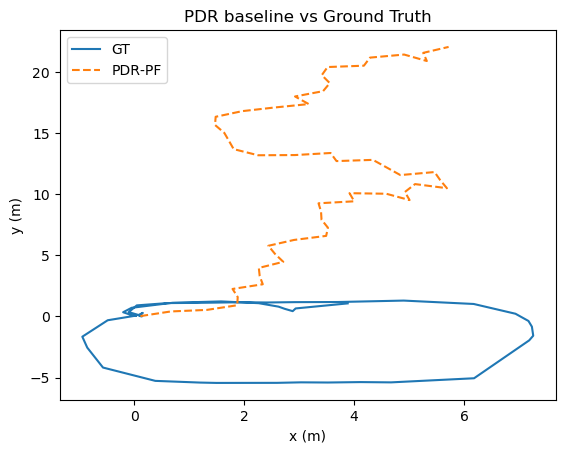

<function matplotlib.pyplot.show(close=None, block=None)>

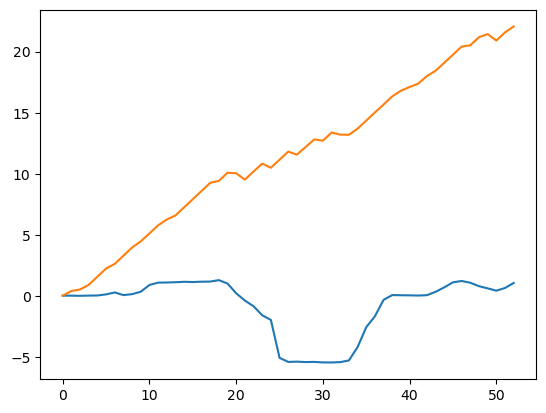

In [34]:
import os
import pandas as pd
import numpy as np
import math
import yaml
from PIL import Image
# import cv2
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import quaternion

# -------------------------------
# 1. Load files
csv_path = './../data/datasets/umgloc_dataset/b1l4c1_3.csv'
yaml_path = './../data/datasets/umgloc_dataset/b1l4c1_3.yaml'
img_path  = './../data/datasets/umgloc_dataset/b1l4c1_3.pgm'  # supplied map image

df = pd.read_csv(csv_path)

# 2. Column mapping (user-specified names)
cols = {
    'ts': 'time_stamp',           # milliseconds
    'ax': 'acceleration_x',
    'ay': 'acceleration_y',
    'az': 'acceleration_z',
    'gx': 'angular_velocity_x',
    'gy': 'angular_velocity_y',
    'gz': 'angular_velocity_z',
    'qw': 'game_rotation_mag',        # w
    'qx': 'game_rotation_x',
    'qy': 'game_rotation_y',
    'qz': 'game_rotation_z',
    'px': 'position_x',
    'py': 'position_y'
}

data = df[[cols[k] for k in cols]].copy()
data.columns = list(cols.keys())

# # 3. Quaternion utilities
def quat_normalize(q):
    return q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-8)

# def quat_mul(q1, q2):
#     w1,x1,y1,z1 = q1.T
#     w2,x2,y2,z2 = q2.T
#     w = w1*w2 - x1*x2 - y1*y2 - z1*z2
#     x = w1*x2 + x1*w2 + y1*z2 - z1*y2
#     y = w1*y2 - x1*z2 + y1*w2 + z1*x2
#     z = w1*z2 + x1*y2 - y1*x2 + z1*w2
#     return np.vstack([w,x,y,z]).T

# def rotate_vectors(q, v):
#     qn = quat_normalize(q)
#     q_conj = qn * np.array([1,-1,-1,-1])
#     v_quat = np.concatenate([np.zeros((v.shape[0],1)), v], axis=1)
#     tmp = quat_mul(qn, v_quat)
#     rotated = quat_mul(tmp, q_conj)
#     return rotated[:,1:]

def transform_imu_to_hacf(gyro, acc, game_rv_quats):
        """
        Transforms raw IMU data (gyro, acc) to a gravity-aligned frame using Game Rotation Vector.
    
        Args:
            gyro: [N, 3] angular velocity in device local frame
            acc: [N, 3] linear acceleration in device local frame
            game_rv_quats: [N, 4] quaternion [w, x, y, z] from Android Game Rotation Vector
    
        Returns:
            gyro_hacf: [N, 3] gyro rotated to HACF (gravity-aligned frame)
            acc_hacf: [N, 3] acc rotated to HACF (gravity-aligned frame)
        """
    
        # Convert to quaternion array
        q_array = quaternion.from_float_array(game_rv_quats)
    
        # Convert gyro and acc vectors to pure quaternions
        gyro_q = quaternion.from_float_array(np.concatenate(
            [np.zeros((gyro.shape[0], 1)), gyro], axis=1
        ))
        acc_q = quaternion.from_float_array(np.concatenate(
            [np.zeros((acc.shape[0], 1)), acc], axis=1
        ))
    
        # Rotate vectors: q * v * q_conj
        gyro_rotated = q_array * gyro_q * q_array.conj()
        acc_rotated = q_array * acc_q * q_array.conj()
    
        # Extract rotated vectors
        gyro_hacf = quaternion.as_float_array(gyro_rotated)[:, 1:]
        acc_hacf = quaternion.as_float_array(acc_rotated)[:, 1:]
    
        return gyro_hacf, acc_hacf
    
# 4. Transform IMU to gravity‑aligned (HACF) frame
quat = data[['qw','qx','qy','qz']].values
acc  = data[['ax','ay','az']].values
gyro = data[['gx','gy','gz']].values
gyro_g, acc_g = transform_imu_to_hacf(gyro, acc, quat)
# 5. Yaw (heading) from quaternion
w,x,y,z = quat_normalize(quat).T
yaw = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))    # rad
plt.plot(acc_g[:, -1])
plt.show()


# 6. Simple step detector (Takaklas thresholds; tuned for 60 Hz)
ACC_LPF = 0.9
acc_mag = acc_g[:, -1]#np.linalg.norm(acc_g, axis=1)
smooth = np.zeros_like(acc_mag)

for i,a in enumerate(acc_mag):
    smooth[i] = a if i==0 else ACC_LPF*smooth[i-1] + (1-ACC_LPF)*a

plt.plot(smooth)
plt.plot(acc_mag)
plt.show()

g0 = np.mean(smooth)           # dynamic baseline
band = 0.5                      # tweak: 0.35–0.60 works well
TH_UP, TH_DN = g0 + band, g0 - band

state, start, peaks = 0, 0, []
for i,a in enumerate(smooth):
    if state==0 and a > TH_UP:
        start = i; state=1
    elif state==1 and a < TH_DN:
        peaks.append((start+i)//2); state=0

# 7. PDR stride integration (0.75 m)
STEP_LEN = 0.67
poses = [data[['px','py']].values[0]]      # anchor at GT origin
for idx in peaks:
    x, y = poses[-1]
    x += STEP_LEN * math.cos(yaw[idx])
    y += STEP_LEN * math.sin(yaw[idx])
    poses.append([x,y])
poses = np.array(poses)

# 8. Load occupancy grid & helpers
with open(yaml_path, 'r') as f:
    meta = yaml.safe_load(f)
resolution = meta['resolution']          # 0.05 m / px
origin     = np.array(meta['origin'])    # map frame origin
img_raw = np.array(Image.open(img_path)).astype(np.float32)
img_norm = (255 - img_raw)/255.0 if meta['negate']==0 else img_raw/255.0
free_thresh = meta['free_thresh']
free = (img_norm < free_thresh).astype(np.uint8)
occ  = 1 - free
h, w = free.shape
dist, nearest_idx = distance_transform_edt(free, return_indices=True)

def world_to_pixel(x, y):
    px = int((x - origin[0]) / resolution)
    py = int((y - origin[1]) / resolution)
    py = h - py - 1
    return px, py

def pixel_to_world(px, py):
    py_inv = h - py - 1
    x = px * resolution + origin[0]
    y = py_inv * resolution + origin[1]
    return x, y
    
gt_positions = data[['px','py']].values[[0]+peaks]

fig = plt.figure()
# plt.imshow(img_norm, origin='upper', extent=[
#     origin[0], origin[0] + w*resolution,
#     origin[1], origin[1] + h*resolution])
plt.plot(gt_positions[:,0], gt_positions[:,1], label='GT')
plt.plot(poses[:,0], poses[:,1], '--', label='PDR‑PF')
plt.legend()
plt.title('PDR baseline vs Ground Truth')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

plt.plot(gt_positions[:,1])
plt.plot(poses[:, 1])
plt.show

In [ ]:
# distance‑to‑free lookup (for snap)



# 9. Snap each pose to free cell
poses_snap = []
for x,y in poses:
    px,py = world_to_pixel(x,y)
    if 0<=px<w and 0<=py<h and free[py,px]:
        poses_snap.append([x,y])
    else:
        py_cl = min(max(py,0),h-1)
        px_cl = min(max(px,0),w-1)
        ny, nx = nearest_idx[0,py_cl,px_cl], nearest_idx[1,py_cl,px_cl]
        sx, sy = pixel_to_world(nx, ny)
        poses_snap.append([sx, sy])
poses_snap = np.array(poses_snap)

# 10. Particle filter (NP=200)
NP = 200
particles = np.tile(poses_snap[0], (NP,1))
weights   = np.ones(NP)/NP
poses_pf  = [poses_snap[0]]
motion_std = 0.05      # m Gaussian noise

for k in range(1, len(poses_snap)):
    delta = poses_snap[k] - poses_snap[k-1]
    particles += delta + np.random.randn(NP,2)*motion_std

    # importance weight = free?1:0
    for i,p in enumerate(particles):
        px,py = world_to_pixel(p[0],p[1])
        if 0<=px<w and 0<=py<h and free[py,px]:
            weights[i] = 1.0
        else:
            weights[i] = 1e-3
    weights /= weights.sum()

    # low‑variance resample
    cdf = np.cumsum(weights)
    u0 = np.random.rand()/NP
    j=0
    new_particles = []
    for m in range(NP):
        u = u0 + m/NP
        while u>cdf[j]:
            j+=1
        new_particles.append(particles[j])
    particles = np.array(new_particles)
    weights.fill(1.0/NP)
    poses_pf.append(particles.mean(axis=0))
poses_pf = np.vstack(poses_pf)

# 11. Save trajectory & compute ADE/FDE
pred_csv = '/mnt/data/pdr_pf_pred.csv'
pd.DataFrame(poses_pf, columns=['x','y']).to_csv(pred_csv, index=False)

gt_positions = data[['px','py']].values[[0]+peaks]
errs = np.linalg.norm(gt_positions - poses_pf, axis=1)
ade = errs.mean()
fde = errs[-1]

print(f"ADE = {ade:.2f} m    FDE = {fde:.2f} m")
print(f"Predicted trajectory saved to: {pred_csv}")

# 12. Quick plot (map + GT + PF)
fig = plt.figure()
plt.imshow(img_norm, origin='upper', extent=[
    origin[0], origin[0] + w*resolution,
    origin[1], origin[1] + h*resolution])
plt.plot(gt_positions[:,0], gt_positions[:,1], label='GT')
plt.plot(poses_pf[:,0], poses_pf[:,1], '--', label='PDR‑PF')
plt.legend()
plt.title('PDR baseline vs Ground Truth')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

ModuleNotFoundError: No module named 'cv2'